In [2]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt 
from dbconfig import engine
print('Environment Ready!')

Environment Ready!


In [92]:
dot_ball_phase_table = pl.read_database(
query = """
with dot_ball_phase_table as (
select match_id,
inning,
batting_team,
case when over between 0 and 5 then 'pp'
when over between 6 and 10 then 'mo'
else 'do' end as phase,
count(*) as total_balls,
count(*) filter(where total_runs = 0) as dot_balls,
winner
from ipl_master_view
where inning in (1,2)
group by match_id, inning, phase, batting_team, winner)

select * from dot_ball_phase_table
order by match_id, inning, phase;
""",
connection = engine)

In [93]:
dot_ball_phase_table.head(6)

match_id,inning,batting_team,phase,total_balls,dot_balls,winner
i64,i64,str,str,i64,i64,str
335982,1,"""Kolkata Knight Riders""","""do""",56,12,"""Kolkata Knight Riders"""
335982,1,"""Kolkata Knight Riders""","""mo""",30,7,"""Kolkata Knight Riders"""
335982,1,"""Kolkata Knight Riders""","""pp""",38,17,"""Kolkata Knight Riders"""
335982,2,"""Royal Challengers Bengaluru""","""do""",28,13,"""Kolkata Knight Riders"""
335982,2,"""Royal Challengers Bengaluru""","""mo""",35,16,"""Kolkata Knight Riders"""
335982,2,"""Royal Challengers Bengaluru""","""pp""",38,21,"""Kolkata Knight Riders"""


In [94]:
dot_ball_phase_table = dot_ball_phase_table.with_columns(
        (pl.col('dot_balls') * 100.00 / pl.col('total_balls')).round(2)
        .alias('dot_ball_pct'))

In [95]:
dot_ball_phase_table.head(6)

match_id,inning,batting_team,phase,total_balls,dot_balls,winner,dot_ball_pct
i64,i64,str,str,i64,i64,str,f64
335982,1,"""Kolkata Knight Riders""","""do""",56,12,"""Kolkata Knight Riders""",21.43
335982,1,"""Kolkata Knight Riders""","""mo""",30,7,"""Kolkata Knight Riders""",23.33
335982,1,"""Kolkata Knight Riders""","""pp""",38,17,"""Kolkata Knight Riders""",44.74
335982,2,"""Royal Challengers Bengaluru""","""do""",28,13,"""Kolkata Knight Riders""",46.43
335982,2,"""Royal Challengers Bengaluru""","""mo""",35,16,"""Kolkata Knight Riders""",45.71
335982,2,"""Royal Challengers Bengaluru""","""pp""",38,21,"""Kolkata Knight Riders""",55.26


In [96]:
dot_ball_phase_table_pivot = dot_ball_phase_table.pivot(
        index = ['match_id', 'inning', 'batting_team', 'winner'],
        on ='phase',
        values = 'dot_ball_pct')

In [97]:
dot_ball_phase_table_pivot.head(6)

match_id,inning,batting_team,winner,do,mo,pp
i64,i64,str,str,f64,f64,f64
335982,1,"""Kolkata Knight Riders""","""Kolkata Knight Riders""",21.43,23.33,44.74
335982,2,"""Royal Challengers Bengaluru""","""Kolkata Knight Riders""",46.43,45.71,55.26
335983,1,"""Chennai Super Kings""","""Chennai Super Kings""",12.5,26.67,50.0
335983,2,"""Punjab Kings""","""Chennai Super Kings""",16.36,6.45,31.58
335984,1,"""Rajasthan Royals""","""Delhi Capitals""",40.0,40.0,54.05
335984,2,"""Delhi Capitals""","""Delhi Capitals""",18.52,25.0,47.37


In [98]:
dot_ball_phase_table_pivot = dot_ball_phase_table_pivot.with_columns(
(pl.col('batting_team') == pl.col('winner'))
.alias('is_winner'))

In [105]:
dot_ball_phase_table_pivot.head(6)

match_id,inning,batting_team,winner,do,mo,pp,is_winner
i64,i64,str,str,f64,f64,f64,bool
335982,1,"""Kolkata Knight Riders""","""Kolkata Knight Riders""",21.43,23.33,44.74,true
335982,2,"""Royal Challengers Bengaluru""","""Kolkata Knight Riders""",46.43,45.71,55.26,false
335983,1,"""Chennai Super Kings""","""Chennai Super Kings""",12.5,26.67,50.0,true
335983,2,"""Punjab Kings""","""Chennai Super Kings""",16.36,6.45,31.58,false
335984,1,"""Rajasthan Royals""","""Delhi Capitals""",40.0,40.0,54.05,false
335984,2,"""Delhi Capitals""","""Delhi Capitals""",18.52,25.0,47.37,true


In [106]:
dot_ball_phase_table_pivot.group_by(
    ["match_id", "is_winner"]
).len().filter(
    pl.col("len") > 1
)

match_id,is_winner,len
i64,bool,u32
1178424,null,2
829813,null,2


In [108]:
dot_ball_phase_table_pivot = dot_ball_phase_table_pivot.filter(
    pl.col("is_winner").is_not_null()
)

In [109]:
dot_ball_phase_table_pivot = dot_ball_phase_table_pivot.pivot(
index = 'match_id',
on = 'is_winner',
values = ['pp', 'mo', 'do'])

In [110]:
dot_ball_phase_table_pivot.head(5)

match_id,pp_true,pp_false,mo_true,mo_false,do_true,do_false
i64,f64,f64,f64,f64,f64,f64
335982,44.74,55.26,23.33,45.71,21.43,46.43
335983,50.0,31.58,26.67,6.45,12.5,16.36
335984,47.37,54.05,25.0,40.0,18.52,40.0
335985,40.54,55.26,29.03,30.0,21.82,27.27
335986,55.56,53.85,69.7,61.29,33.96,45.83


In [111]:
dot_ball_diff = dot_ball_phase_table_pivot.with_columns(
pp_diff = pl.col('pp_true') - pl.col('pp_false'),
mo_diff = pl.col('mo_true') - pl.col('mo_false'),
do_diff = pl.col('do_true') - pl.col('do_false'))

In [114]:
dot_ball_diff.select(
        pl.mean('pp_diff'),
        pl.mean('mo_diff'),
        pl.mean('do_diff'))

pp_diff,mo_diff,do_diff
f64,f64,f64
-3.680028,-3.094054,-5.155509


In [116]:
dot_ball_diff.select(
        pl.median('pp_diff'),
        pl.median('mo_diff'),
        pl.median('do_diff'))

pp_diff,mo_diff,do_diff
f64,f64,f64
-3.77,-3.23,-4.635


In [117]:
dot_ball_diff = dot_ball_diff.with_columns(
    pp_abs = pl.col("pp_diff").abs(),
    mo_abs = pl.col("mo_diff").abs(),
    do_abs = pl.col("do_diff").abs()
)

In [119]:
dot_ball_diff.select(
        pl.mean('pp_abs'),
        pl.mean('mo_abs'),
        pl.mean('do_abs'))

pp_abs,mo_abs,do_abs
f64,f64,f64
10.615385,11.384137,9.763943


In [120]:
dot_ball_diff.select(
        pl.median('pp_abs'),
        pl.median('mo_abs'),
        pl.median('do_abs'))

pp_abs,mo_abs,do_abs
f64,f64,f64
9.11,10.0,8.015


In [135]:
dominant_phase = dot_ball_diff.with_columns(
    pl.concat_list(["pp_abs", "mo_abs", "do_abs"])
      .list.arg_max()
      .replace_strict({
          0: "PP",
          1: "MO",
          2: "DO"
      })
      .alias("dominant_phase"))

In [136]:
dominant_phase_plot = dominant_phase.group_by('dominant_phase').len()

In [138]:
dominant_phase_plot = dominant_phase_plot.with_columns(
    (
        pl.col("len") / pl.col("len").sum() * 100
    ).round(2).alias("pct")
)

In [142]:
win_rate_plot = dot_ball_diff.select(
    (pl.col("pp_diff") < 0).mean().alias("pp"),
    (pl.col("mo_diff") < 0).mean().alias("mo"),
    (pl.col("do_diff") < 0).mean().alias("do"),
)

In [145]:
win_rate_plot = (win_rate_plot.unpivot(
variable_name = 'phase', value_name = 'win_pct').with_columns(
    (pl.col('win_pct') * 100.00).round(2).alias('win_pct')))

In [126]:
dot_ball_diff.select(
    pl.col("pp_abs").quantile(0.75),
    pl.col("mo_abs").quantile(0.75),
    pl.col("do_abs").quantile(0.75),
)

pp_abs,mo_abs,do_abs
f64,f64,f64
15.18,16.66,13.5


In [128]:
plot_df = dot_ball_diff.select('pp_abs', 'mo_abs', 'do_abs').unpivot(variable_name = 'phase', value_name = 'abs_diff')

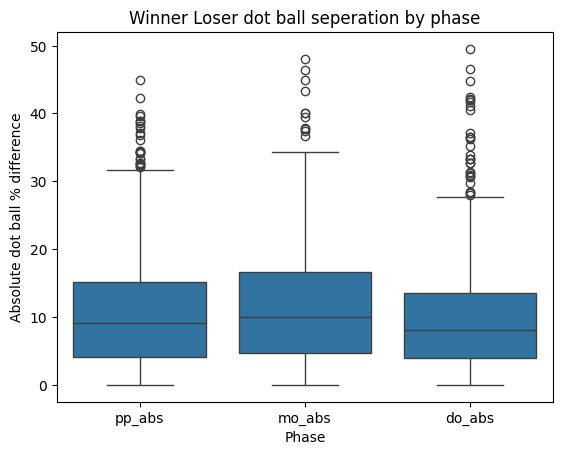

In [129]:
sns.boxplot(data = plot_df, x = 'phase', y = 'abs_diff')
plt.ylabel('Absolute dot ball % difference')
plt.xlabel('Phase')
plt.title('Winner Loser dot ball seperation by phase')
plt.savefig(
    "plots/dot_ball_phase_seperation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

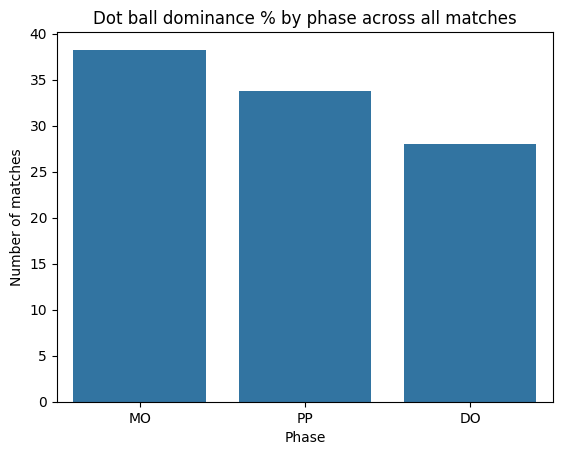

In [139]:
sns.barplot(data = dominant_phase_plot, x = 'dominant_phase', y = 'pct')
plt.ylabel('Number of matches')
plt.xlabel('Phase')
plt.title('Dot ball dominance % by phase across all matches')
plt.savefig(
    "plots/dot_ball_phase_dominance_count.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

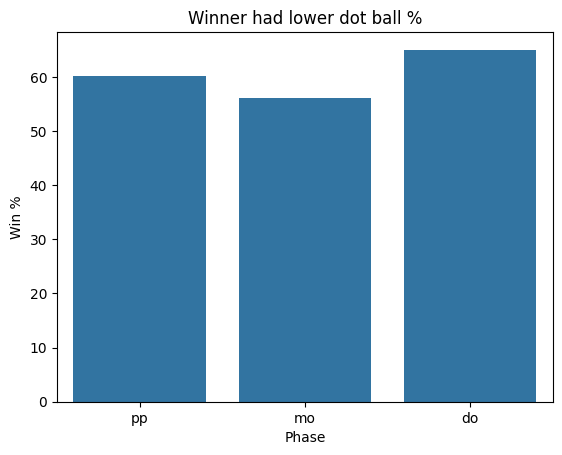

In [146]:
sns.barplot(data = win_rate_plot, x = 'phase', y = 'win_pct')
plt.ylabel('Win %')
plt.xlabel('Phase')
plt.title('Winner had lower dot ball %')
plt.savefig(
    "plots/winner_win%_by_phase.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [151]:
from scipy.stats import friedmanchisquare

friedman_df = dot_ball_diff.drop_nulls(
    subset=["pp_abs", "mo_abs", "do_abs"]
)
stat, p = friedmanchisquare(
    friedman_df["pp_abs"],
    friedman_df["mo_abs"],
    friedman_df["do_abs"]
)

print(f"Statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

Statistic: 11.0012
P-value: 0.004084


In [149]:
dot_ball_diff.select(
    pl.col("pp_abs").null_count(),
    pl.col("mo_abs").null_count(),
    pl.col("do_abs").null_count()
)

pp_abs,mo_abs,do_abs
u32,u32,u32
0,7,30


In [150]:
dot_ball_diff.select(
    pl.col("pp_abs").is_nan().sum(),
    pl.col("mo_abs").is_nan().sum(),
    pl.col("do_abs").is_nan().sum()
)

pp_abs,mo_abs,do_abs
u32,u32,u32
0,0,0


In [152]:
from scipy.stats import wilcoxon

mo_pp = wilcoxon(
    friedman_df["mo_abs"],
    friedman_df["pp_abs"]
)

mo_do = wilcoxon(
    friedman_df["mo_abs"],
    friedman_df["do_abs"]
)

pp_do = wilcoxon(
    friedman_df["pp_abs"],
    friedman_df["do_abs"]
)

print("MO vs PP:", mo_pp)
print("MO vs DO:", mo_do)
print("PP vs DO:", pp_do)

MO vs PP: WilcoxonResult(statistic=np.float64(257926.0), pvalue=np.float64(0.02254471943068888))
MO vs DO: WilcoxonResult(statistic=np.float64(237346.5), pvalue=np.float64(1.106524803110851e-05))
PP vs DO: WilcoxonResult(statistic=np.float64(255382.5), pvalue=np.float64(0.00970613709043814))


In [153]:
comparisons = {
    "MO vs PP": mo_pp,
    "MO vs DO": mo_do,
    "PP vs DO": pp_do,
}

for name, result in comparisons.items():
    print(
        f"{name}: statistic={result.statistic:.1f}, "
        f"p-value={result.pvalue:.6f}"
    )

MO vs PP: statistic=257926.0, p-value=0.022545
MO vs DO: statistic=237346.5, p-value=0.000011
PP vs DO: statistic=255382.5, p-value=0.009706


In [155]:
phase_win_df = dot_ball_diff.with_columns(
    pp_win = pl.col("pp_diff") < 0,
    mo_win = pl.col("mo_diff") < 0,
    do_win = pl.col("do_diff") < 0)
phase_win_df.head(5)

match_id,pp_true,pp_false,mo_true,mo_false,do_true,do_false,pp_diff,mo_diff,do_diff,pp_abs,mo_abs,do_abs,pp_win,mo_win,do_win
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool
335982,44.74,55.26,23.33,45.71,21.43,46.43,-10.52,-22.38,-25.0,10.52,22.38,25.0,true,true,true
335983,50.0,31.58,26.67,6.45,12.5,16.36,18.42,20.22,-3.86,18.42,20.22,3.86,false,false,true
335984,47.37,54.05,25.0,40.0,18.52,40.0,-6.68,-15.0,-21.48,6.68,15.0,21.48,true,true,true
335985,40.54,55.26,29.03,30.0,21.82,27.27,-14.72,-0.97,-5.45,14.72,0.97,5.45,true,true,true
335986,55.56,53.85,69.7,61.29,33.96,45.83,1.71,8.41,-11.87,1.71,8.41,11.87,false,false,true


In [160]:
from statsmodels.stats.contingency_tables import cochrans_q

cochrans_q_df = phase_win_df.drop_nulls(
    subset=["pp_abs", "mo_abs", "do_abs"])

result = cochrans_q(
        cochrans_q_df.select(
    "pp_win",
    "mo_win",
    "do_win"
))

print(result)

df          2
pvalue      6.344326072878346e-05
statistic   19.330729166666668


In [161]:
from statsmodels.stats.contingency_tables import mcnemar

pp_do = (
    cochrans_q_df
    .group_by(["pp_win", "do_win"])
    .len()
)

pp_do

pp_win,do_win,len
bool,bool,u32
true,true,387
false,true,302
false,false,127
true,false,244


In [162]:
table = [
    [387, 244],
    [302, 127]
]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print(result)

pvalue      0.01471269958503877
statistic   5.950549450549451


In [163]:
cochrans_q_df.group_by(
    ["pp_win", "mo_win"]
).len()

pp_win,mo_win,len
bool,bool,u32
true,false,267
false,true,226
true,true,364
false,false,203


In [164]:
table = [
    [364, 267],
    [226, 203]
]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print(result)

pvalue      0.07162262761341881
statistic   3.2454361054766734


In [165]:
cochrans_q_df.group_by(
    ["mo_win", "do_win"]
).len()

mo_win,do_win,len
bool,bool,u32
false,false,172
true,false,199
true,true,391
false,true,298


In [166]:
table = [
    [391, 199],
    [298, 172]
]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print(result)

pvalue      1.1031431902362932e-05
statistic   19.323943661971832
